# **Importing Necessary packages**

In [1]:
# start by importing all nesassary  packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
# you can import other models as needed e.g., from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor


# **Downloading the dataset from kaggle**

In [2]:
import pandas as pd
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# Load the dataset
data = pd.read_csv('data/kc_house_data.csv')

# Function to display dataset information and a sample
def display_data(n_rows=5):
    #display(data.describe(include='all'))  # show the description
    display(data.head(n_rows))

# Create an interactive widget
interact(display_data, n_rows=widgets.IntSlider(min=1, max=len(data), step=1, value=5));

print(data.columns)

interactive(children=(IntSlider(value=5, description='n_rows', max=21613, min=1), Output()), _dom_classes=('wi…

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')


# **Data Selection**

In [3]:
selected_features = ['bedrooms', 'bathrooms','floors', 'grade', 'yr_built' , 'zipcode', 'price']
new_df = data[selected_features]

from ipywidgets import interact
def show_rows(n):
    display(new_df.head(n))
interact(show_rows, n=(1, new_df.size)) # Interactive slider to show new_df rows

interactive(children=(IntSlider(value=75646, description='n', max=151291, min=1), Output()), _dom_classes=('wi…

<function __main__.show_rows(n)>

# **Data Visualisation**

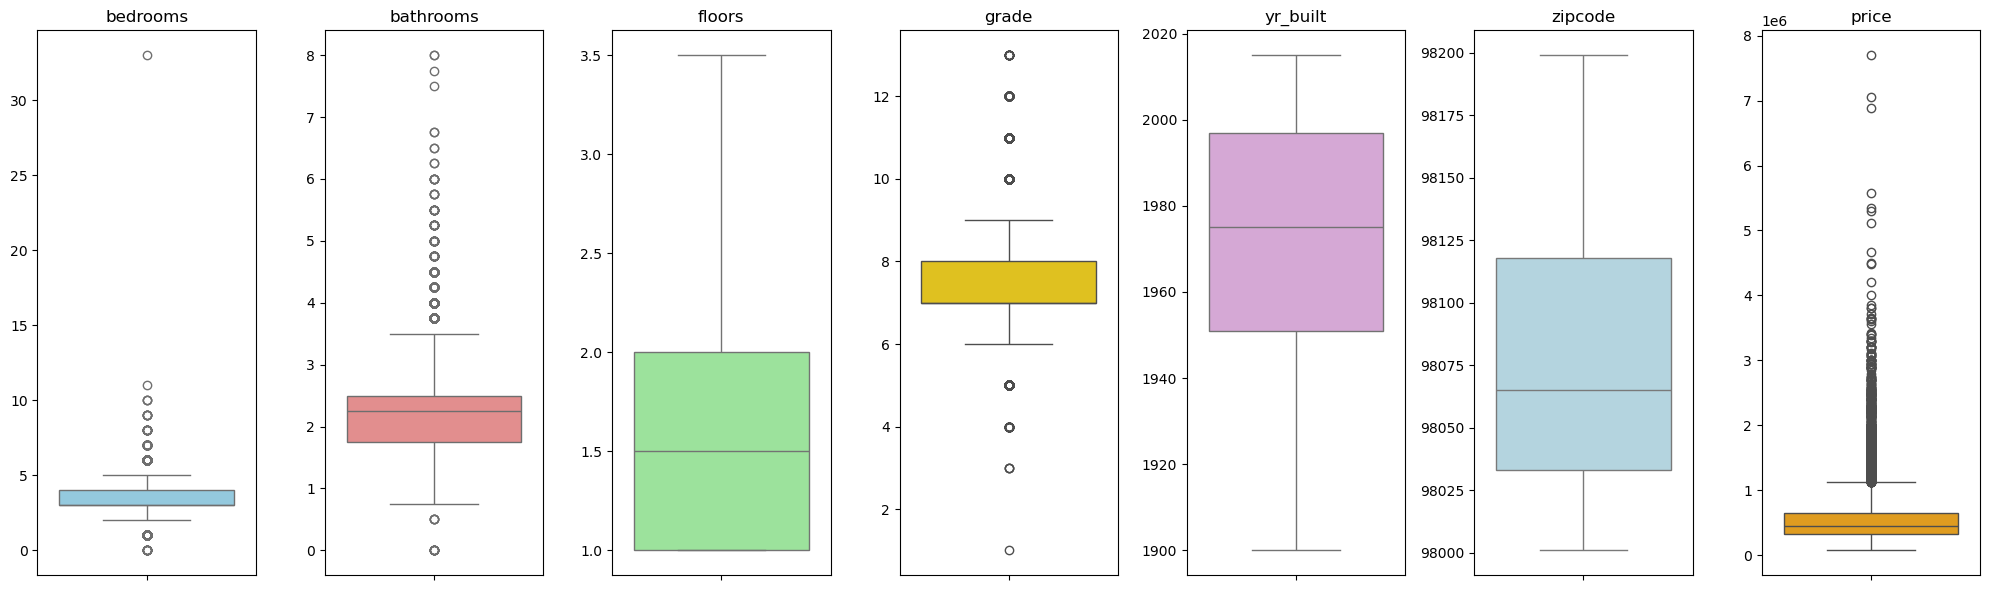

In [4]:
plt.figure(figsize=(20, 6))  # Adjust figure size for better visualization

# Define a list of colors for the boxplots
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'lightblue', 'orange']

# Iterate through each column in new_df and create a boxplot
for i, col in enumerate(new_df.columns):
    plt.subplot(1, len(new_df.columns), i + 1)  # Create subplots in a single row
    sns.boxplot(y=new_df[col], color=colors[i % len(colors)])  # Use colors from the list
    plt.title(col)
    plt.ylabel('')  # Remove y-axis label for cleaner look

plt.tight_layout() # Adjust subplot parameters for a tight layout.
plt.show()


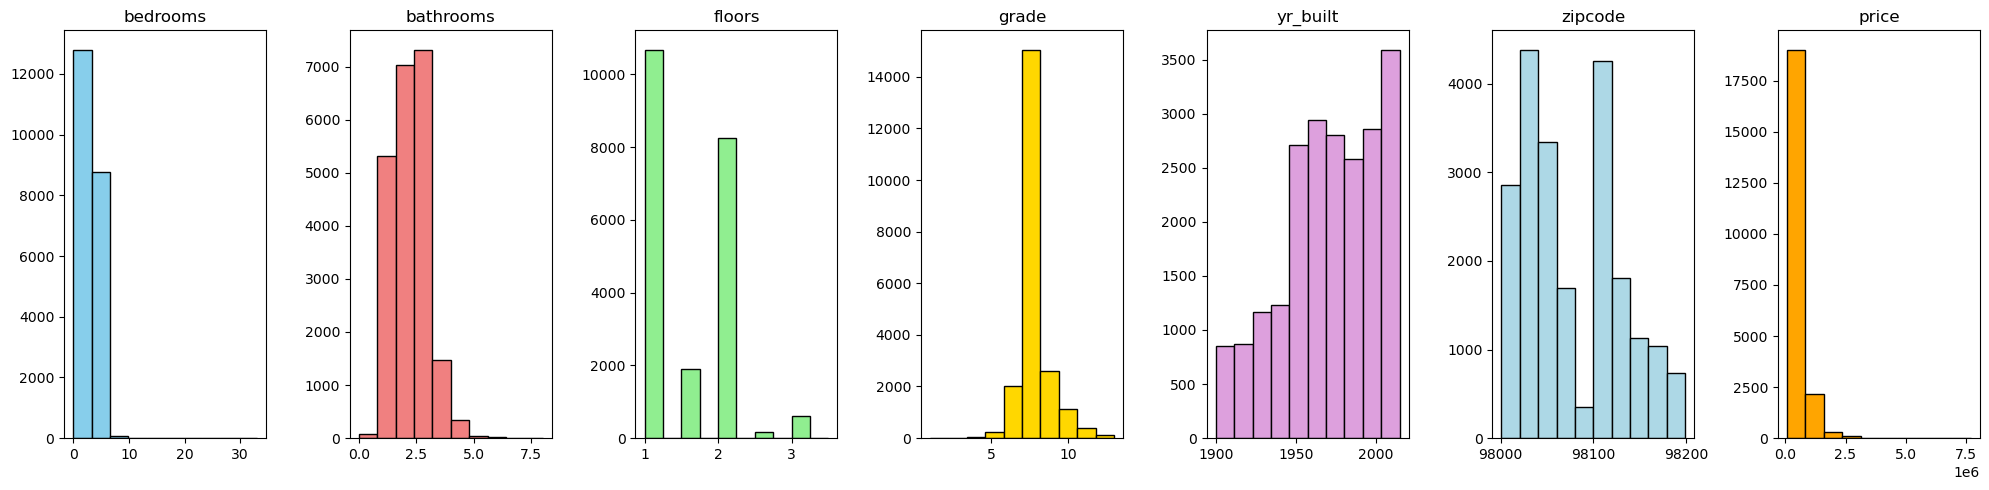

In [5]:
plt.figure(figsize=(20, 5))  # Adjust figure size for better visualization

# Define a list of colors for the histograms
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'lightblue', 'orange']

# Iterate through each column in new_df and create a histogram
for i, col in enumerate(new_df.columns):
    plt.subplot(1, len(new_df.columns), i + 1)  # Create subplots in a single row
    plt.hist(new_df[col], color=colors[i % len(colors)], edgecolor='black') #added edgecolor
    plt.title(col)
    plt.ylabel('')  # Remove y-axis label for cleaner look
    plt.xlabel('') #remove x-axis label

plt.tight_layout()
plt.show()


# **Data Cleaning**

In [6]:
# Function to replace outliers with the median value based on IQR
#def replace_outliers_with_median(df, col):
#    Q1 = df[col].quantile(0.25)
 #   Q3 = df[col].quantile(0.75)
  #  IQR = Q3 - Q1
   # lower_bound = Q1 - 1.5 * IQR
    #upper_bound = Q3 + 1.5 * IQR
    #df[col] = np.where((df[col] < lower_bound) | (df[col] > upper_bound), df[col].median(), df[col])
    #return df

# Columns to process
#cols_to_process = ['bedrooms', 'bathrooms', 'floors', 'grade', 'yr_built', 'price']

# Apply the outlier replacement function to the specified columns
#for col in cols_to_process:
 #   new_df = replace_outliers_with_median(new_df, col)


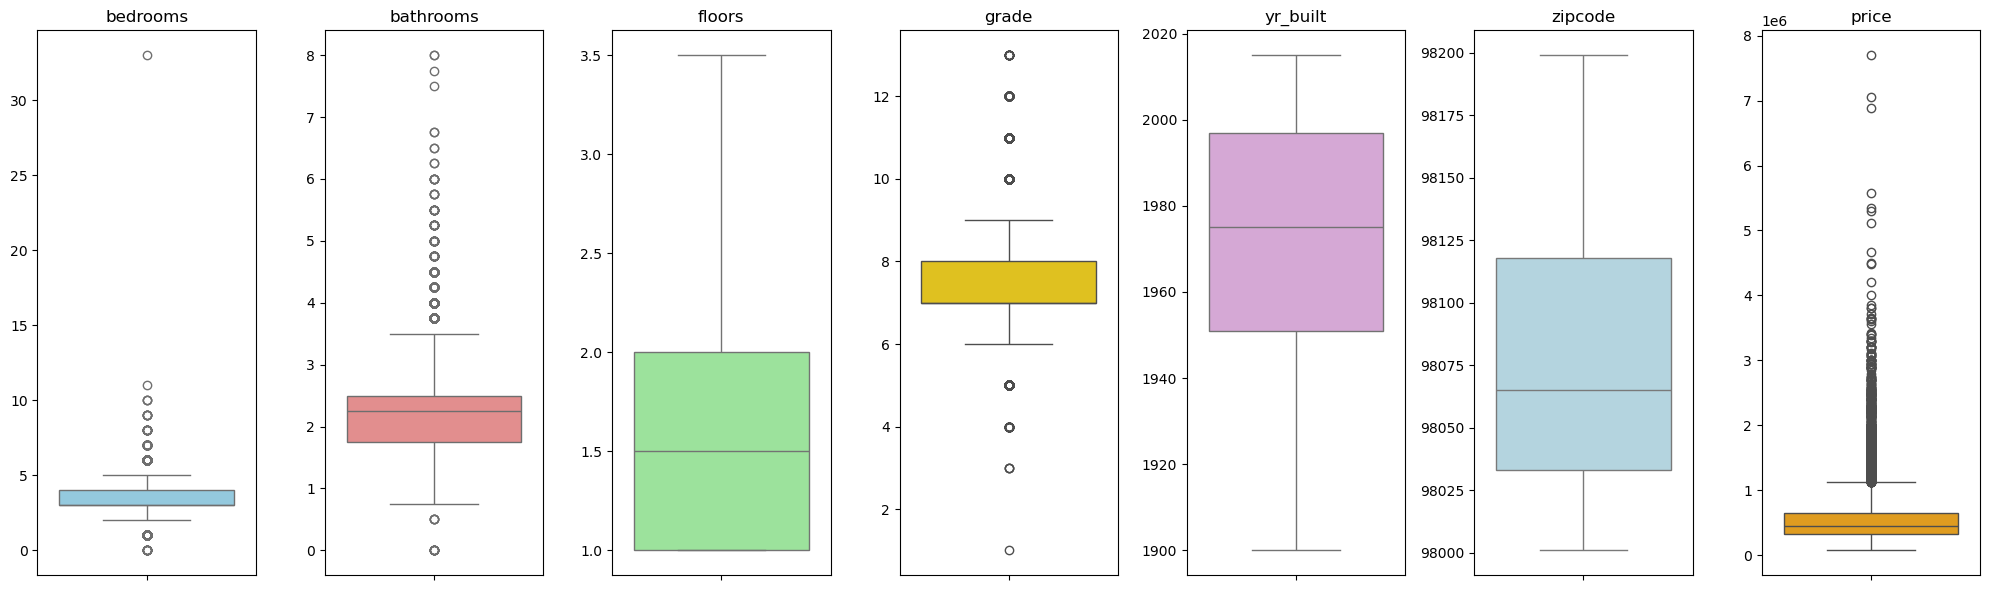

In [7]:
plt.figure(figsize=(20, 6))  # Adjust figure size for better visualization

# Define a list of colors for the boxplots
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'lightblue', 'orange']

# Iterate through each column in new_df and create a boxplot
for i, col in enumerate(new_df.columns):
    plt.subplot(1, len(new_df.columns), i + 1)  # Create subplots in a single row
    sns.boxplot(y=new_df[col], color=colors[i % len(colors)])  # Use colors from the list
    plt.title(col)
    plt.ylabel('')  # Remove y-axis label for cleaner look

plt.tight_layout() # Adjust subplot parameters for a tight layout.
plt.show()


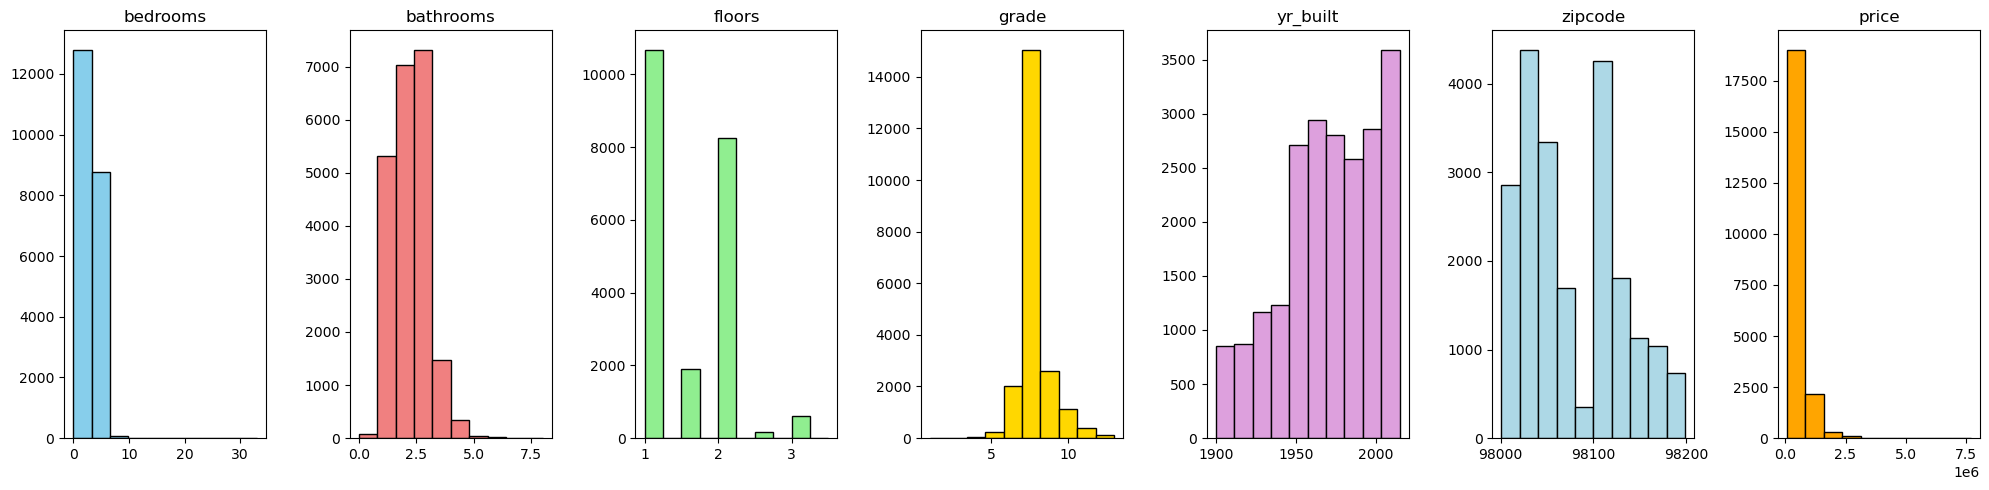

In [8]:
plt.figure(figsize=(20, 5))  # Adjust figure size for better visualization

# Define a list of colors for the histograms
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'lightblue', 'orange']

# Iterate through each column in new_df and create a histogram
for i, col in enumerate(new_df.columns):
    plt.subplot(1, len(new_df.columns), i + 1)  # Create subplots in a single row
    plt.hist(new_df[col], color=colors[i % len(colors)], edgecolor='black') #added edgecolor
    plt.title(col)
    plt.ylabel('')  # Remove y-axis label for cleaner look
    plt.xlabel('') #remove x-axis label

plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [9]:
# Separate features (X) and target variable (y)
X = new_df.drop('price', axis=1)
y = new_df['price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test_scaled = scaler.transform(X_test)


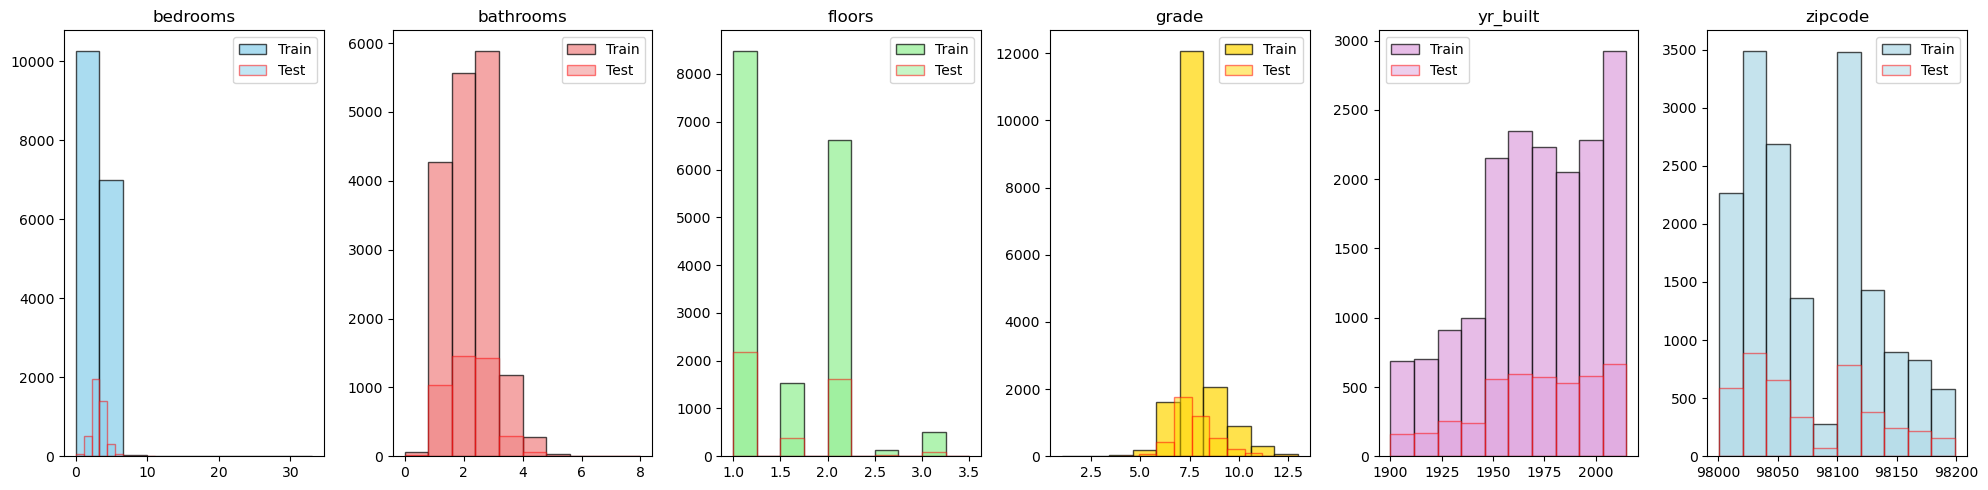

In [10]:
plt.figure(figsize=(20, 5))  # Adjust figure size for better visualization

# Define a list of colors for the histograms
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'lightblue', 'orange']

# Iterate through each column in X_train and create a histogram
for i, col in enumerate(X_train.columns):
    plt.subplot(1, len(X_train.columns), i + 1)  # Create subplots in a single row
    plt.hist(X_train[col], color=colors[i % len(colors)], edgecolor='black', alpha=0.7, label='Train') #added edgecolor
    plt.hist(X_test[col], color=colors[i % len(colors)], edgecolor='red', alpha=0.5, label='Test') #added edgecolor
    plt.title(col)
    plt.ylabel('')  # Remove y-axis label for cleaner look
    plt.xlabel('') #remove x-axis label
    plt.legend()

plt.tight_layout()
plt.show()


# **Models selections**

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Initialize the models
linear_regression_model = LinearRegression()
svm_model = SVR()
mlp_model = MLPRegressor()


# **Training and testing the models**

In [12]:
# Train the linear regression model
linear_regression_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lr = linear_regression_model.predict(X_test_scaled)

# Evaluate the linear regression model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression:")
print(f"Mean Squared Error: {mse_lr}")
print(f"R-squared: {r2_lr}")

# ## **Support Vector Machine (SVM)**
# Train the SVM model
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate the SVM model
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("\nSupport Vector Machine:")
print(f"Mean Squared Error: {mse_svm}")
print(f"R-squared: {r2_svm}")

# ## **Multi-layer Perceptron (MLP)**
# Train the MLP model
mlp_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_mlp = mlp_model.predict(X_test_scaled)

# Evaluate the MLP model
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("\nMulti-layer Perceptron:")
print(f"Mean Squared Error: {mse_mlp}")
print(f"R-squared: {r2_mlp}")


Linear Regression:
Mean Squared Error: 67347243122.23028
R-squared: 0.5545131117297746

Support Vector Machine:
Mean Squared Error: 160710179214.46222
R-squared: -0.06306174287880939

Multi-layer Perceptron:
Mean Squared Error: 355974449015.48096
R-squared: -1.3546910347584693


In [13]:
models = {
    "Linear Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Multi-layer Prec": y_pred_mlp
}

results = []

for name, preds in models.items():
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append([name, mse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MSE (Test)", "R2 (Test)"]
)

display(results_df)


,Model,MSE (Test),R2 (Test)
0,Linear Regression,6.734724e+10,0.554513
1,SVM,1.607102e+11,-0.063062
2,Multi-layer Prec,3.559744e+11,-1.354691


# **Improving MLP model**

In [14]:
# Try different activation functions
mlp_model_relu = MLPRegressor(activation='relu', hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp_model_relu.fit(X_train_scaled, y_train)
y_pred_mlp_relu = mlp_model_relu.predict(X_test_scaled)
mse_mlp_relu = mean_squared_error(y_test, y_pred_mlp_relu)
r2_mlp_relu = r2_score(y_test, y_pred_mlp_relu)

print("\nMulti-layer Perceptron (ReLU):")
print(f"Mean Squared Error: {mse_mlp_relu}")
print(f"R-squared: {r2_mlp_relu}")

# Increase the number of hidden layers and neurons
mlp_model_large = MLPRegressor(hidden_layer_sizes=(200, 100, 50), max_iter=1000, random_state=42)
mlp_model_large.fit(X_train_scaled, y_train)
y_pred_mlp_large = mlp_model_large.predict(X_test_scaled)
mse_mlp_large = mean_squared_error(y_test, y_pred_mlp_large)
r2_mlp_large = r2_score(y_test, y_pred_mlp_large)

print("\nMulti-layer Perceptron (Larger Network):")
print(f"Mean Squared Error: {mse_mlp_large}")
print(f"R-squared: {r2_mlp_large}")

# Adjust the learning rate and other hyperparameters
mlp_model_tuned = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, learning_rate_init=0.001, random_state=42)
mlp_model_tuned.fit(X_train_scaled, y_train)
y_pred_mlp_tuned = mlp_model_tuned.predict(X_test_scaled)
mse_mlp_tuned = mean_squared_error(y_test, y_pred_mlp_tuned)
r2_mlp_tuned = r2_score(y_test, y_pred_mlp_tuned)

print("\nMulti-layer Perceptron (Tuned Hyperparameters):")
print(f"Mean Squared Error: {mse_mlp_tuned}")
print(f"R-squared: {r2_mlp_tuned}")



Multi-layer Perceptron (ReLU):
Mean Squared Error: 57290352426.30986
R-squared: 0.6210371850859492

Multi-layer Perceptron (Larger Network):
Mean Squared Error: 52831010378.5757
R-squared: 0.6505347312434389

Multi-layer Perceptron (Tuned Hyperparameters):
Mean Squared Error: 55350925508.85977
R-squared: 0.6338660585843681


In [15]:
models = {
    "MLP (ReLU)": y_pred_mlp_relu,
    "MLP (Large)": y_pred_mlp_large,
    "MLP (Tuned)": y_pred_mlp_tuned
}

results = []

for name, preds in models.items():
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append([name, mse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MSE (Test)", "R2 (Test)"]
)

display(results_df)

,Model,MSE (Test),R2 (Test)
0,MLP (ReLU),5.729035e+10,0.621037
1,MLP (Large),5.283101e+10,0.650535
2,MLP (Tuned),5.535093e+10,0.633866


In [16]:
models = {
    "Linear Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Multi-layer Prec": y_pred_mlp,
    "MLP (ReLU)": y_pred_mlp_relu,
    "MLP (Large)": y_pred_mlp_large,
    "MLP (Tuned)": y_pred_mlp_tuned
}

results = []

for name, preds in models.items():
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append([name, mse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MSE (Test)", "R2 (Test)"]
)

display(results_df)

,Model,MSE (Test),R2 (Test)
0,Linear Regression,6.734724e+10,0.554513
1,SVM,1.607102e+11,-0.063062
2,Multi-layer Prec,3.559744e+11,-1.354691
3,MLP (ReLU),5.729035e+10,0.621037
4,MLP (Large),5.283101e+10,0.650535
5,MLP (Tuned),5.535093e+10,0.633866


# **Deploying the best model**

In [17]:
import pickle

# Save best model
pickle.dump(mlp_model_large, open("models/model.sav", "wb"))

# Save scaler
pickle.dump(scaler, open("models/scaler.sav", "wb"))

# Save evaluation metric
pickle.dump(r2_mlp_large, open("models/r2.sav", "wb"))

print("Model, scaler, and R2 saved successfully.")


Model, scaler, and R2 saved successfully.


In [18]:
import pickle

# Load the saved model (Ajout du dossier 'models/')
loaded_model = pickle.load(open('models/model.sav', 'rb'))

# Now you can use the loaded_model to make predictions
# Example:
# new_data = ...  # Your new data as a NumPy array or DataFrame
# predictions = loaded_model.predict(new_data)
